<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/09_fifa22_players_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/EDA/fifa/players_22.csv'
)

df.head()

Mounted at /content/drive


/tmp/ipykernel_1926/2565908586.py:4: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [3]:
df.shape

(19239, 110)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: float64(16), int64(44), object(50)
memory usage: 16.1+ MB


In [5]:
df.columns.tolist()

['sofifa_id',
 'player_url',
 'short_name',
 'long_name',
 'player_positions',
 'overall',
 'potential',
 'value_eur',
 'wage_eur',
 'age',
 'dob',
 'height_cm',
 'weight_kg',
 'club_team_id',
 'club_name',
 'league_name',
 'league_level',
 'club_position',
 'club_jersey_number',
 'club_loaned_from',
 'club_joined',
 'club_contract_valid_until',
 'nationality_id',
 'nationality_name',
 'nation_team_id',
 'nation_position',
 'nation_jersey_number',
 'preferred_foot',
 'weak_foot',
 'skill_moves',
 'international_reputation',
 'work_rate',
 'body_type',
 'real_face',
 'release_clause_eur',
 'player_tags',
 'player_traits',
 'pace',
 'shooting',
 'passing',
 'dribbling',
 'defending',
 'physic',
 'attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_agi

In [6]:
# Select a relevant subset of columns
cols = ['short_name', 'age', 'nationality_name', 'club_name', 'player_positions',
        'overall', 'potential', 'value_eur', 'wage_eur', 'pace', 'shooting',
        'passing', 'dribbling', 'defending', 'physic', 'height_cm', 'weight_kg']

df = df[cols].copy()
df.head()

,short_name,age,nationality_name,club_name,player_positions,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,height_cm,weight_kg
0,L. Messi,34,Argentina,Paris Saint-Germain,"RW, ST, CF",93,93,78000000.0,320000.0,85.0,92.0,91.0,95.0,34.0,65.0,170,72
1,R. Lewandowski,32,Poland,FC Bayern München,ST,92,92,119500000.0,270000.0,78.0,92.0,79.0,86.0,44.0,82.0,185,81
2,Cristiano Ronaldo,36,Portugal,Manchester United,"ST, LW",91,91,45000000.0,270000.0,87.0,94.0,80.0,88.0,34.0,75.0,187,83
3,Neymar Jr,29,Brazil,Paris Saint-Germain,"LW, CAM",91,91,129000000.0,270000.0,91.0,83.0,86.0,94.0,37.0,63.0,175,68
4,K. De Bruyne,30,Belgium,Manchester City,"CM, CAM",91,91,125500000.0,350000.0,76.0,86.0,93.0,88.0,64.0,78.0,181,70


In [7]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
dribbling,2132
shooting,2132
passing,2132
physic,2132
defending,2132
pace,2132
value_eur,74
wage_eur,61
club_name,61
short_name,0


In [8]:
# pace/shooting/passing/dribbling/defending/physic are NaN for goalkeepers - expected, not an error
df[df['pace'].isnull()]['player_positions'].value_counts().head()

,count
player_positions,
GK,2132


In [9]:
# Keep GK rows but flag them clearly rather than dropping or imputing incorrectly
df['is_goalkeeper'] = df['player_positions'].str.contains('GK')

# Drop rows missing essential fields (value, wage - very few, likely free agents/data gaps)
df = df.dropna(subset=['value_eur', 'wage_eur', 'overall'])
df.shape

(19165, 18)

In [10]:
# Extract primary position (first listed in player_positions)
df['primary_position'] = df['player_positions'].str.split(',').str[0].str.strip()

# Map to broader position groups
position_map = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender',
    'CDM': 'Midfielder', 'CM': 'Midfielder', 'CAM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder',
    'ST': 'Forward', 'CF': 'Forward', 'LW': 'Forward', 'RW': 'Forward'
}
df['position_group'] = df['primary_position'].map(position_map)

df[['player_positions', 'primary_position', 'position_group']].head(10)

,player_positions,primary_position,position_group
0,"RW, ST, CF",RW,Forward
1,ST,ST,Forward
2,"ST, LW",ST,Forward
3,"LW, CAM",LW,Forward
4,"CM, CAM",CM,Midfielder
5,GK,GK,Goalkeeper
6,"ST, LW",ST,Forward
7,GK,GK,Goalkeeper
8,GK,GK,Goalkeeper
9,ST,ST,Forward


In [11]:
# Check for any unmapped positions
df[df['position_group'].isnull()]['primary_position'].unique()

array([], dtype=object)

In [12]:
# Check duplicates
df = df.drop_duplicates()
df.shape

(19165, 20)

**3. Univariate Analysis**

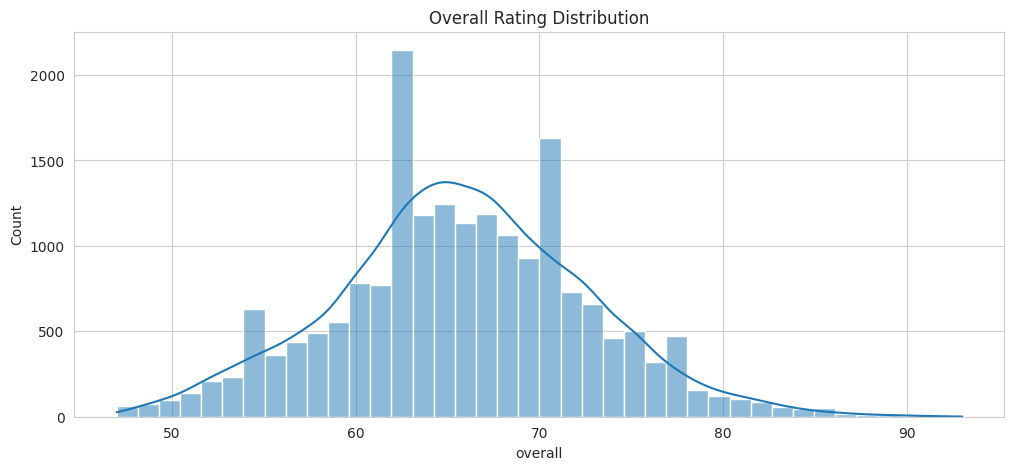

In [13]:
# Overall rating distribution
plt.figure(figsize=(12,5))
sns.histplot(df['overall'], bins=40, kde=True)
plt.title('Overall Rating Distribution')
plt.show()

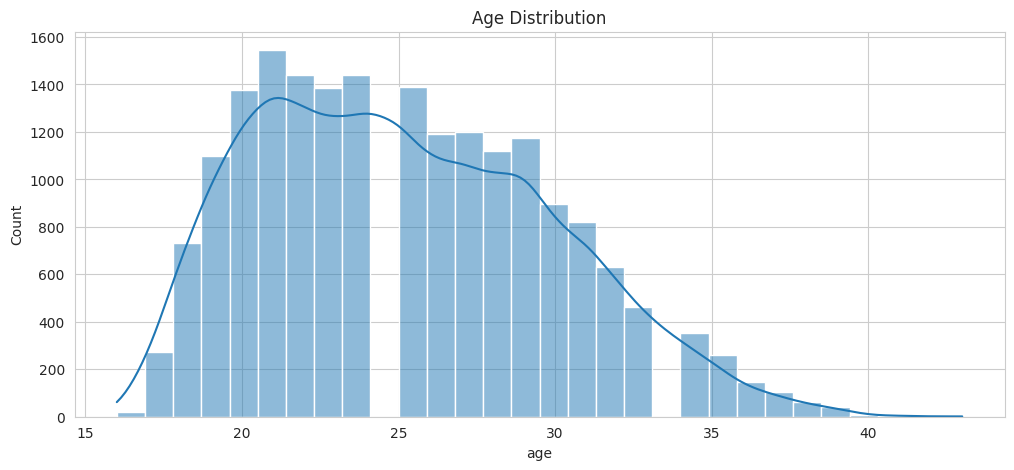

In [14]:
# Age distribution
plt.figure(figsize=(12,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

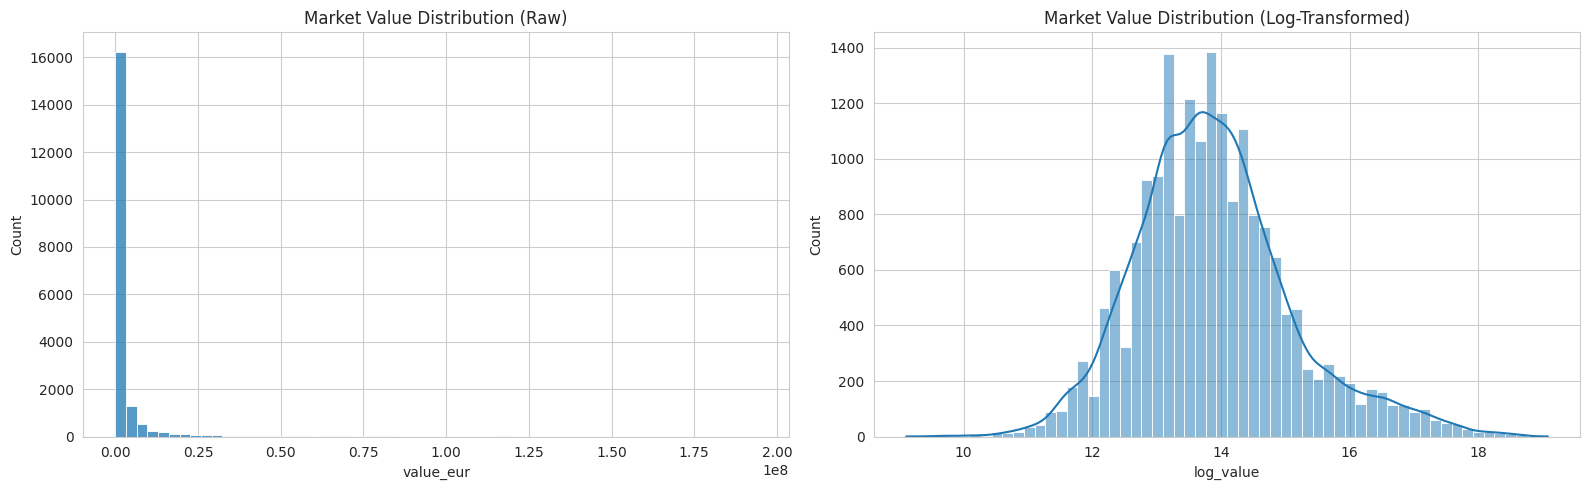

In [15]:
# Value distribution - raw and log-transformed
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.histplot(df['value_eur'], bins=60, ax=axes[0])
axes[0].set_title('Market Value Distribution (Raw)')

df['log_value'] = np.log1p(df['value_eur'])
sns.histplot(df['log_value'], bins=60, kde=True, ax=axes[1])
axes[1].set_title('Market Value Distribution (Log-Transformed)')

plt.tight_layout()
plt.show()

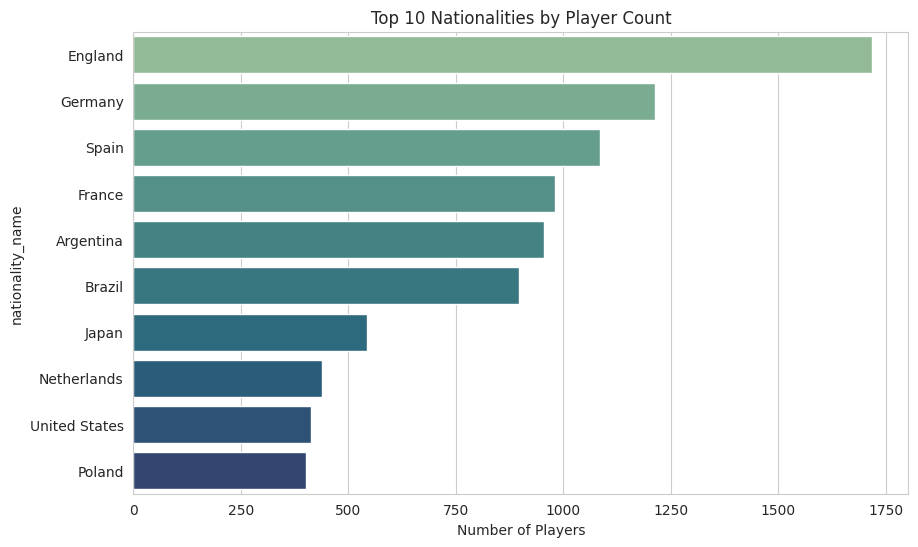

In [16]:
# Top 10 nationalities by player count
top_nat = df['nationality_name'].value_counts().head(10)

sns.barplot(x=top_nat.values, y=top_nat.index, hue=top_nat.index, palette='crest', legend=False)
plt.title('Top 10 Nationalities by Player Count')
plt.xlabel('Number of Players')
plt.show()

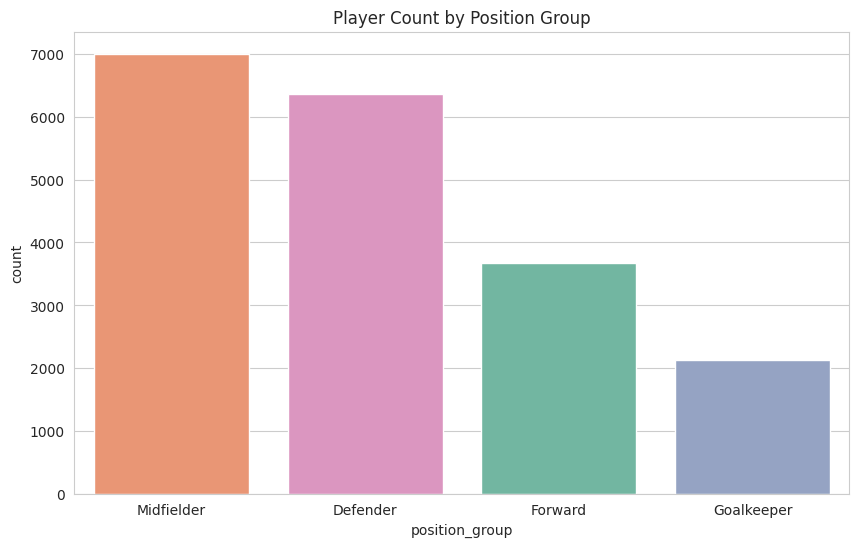

In [17]:
# Distribution by position group
sns.countplot(data=df, x='position_group', hue='position_group', palette='Set2', legend=False,
              order=df['position_group'].value_counts().index)
plt.title('Player Count by Position Group')
plt.show()

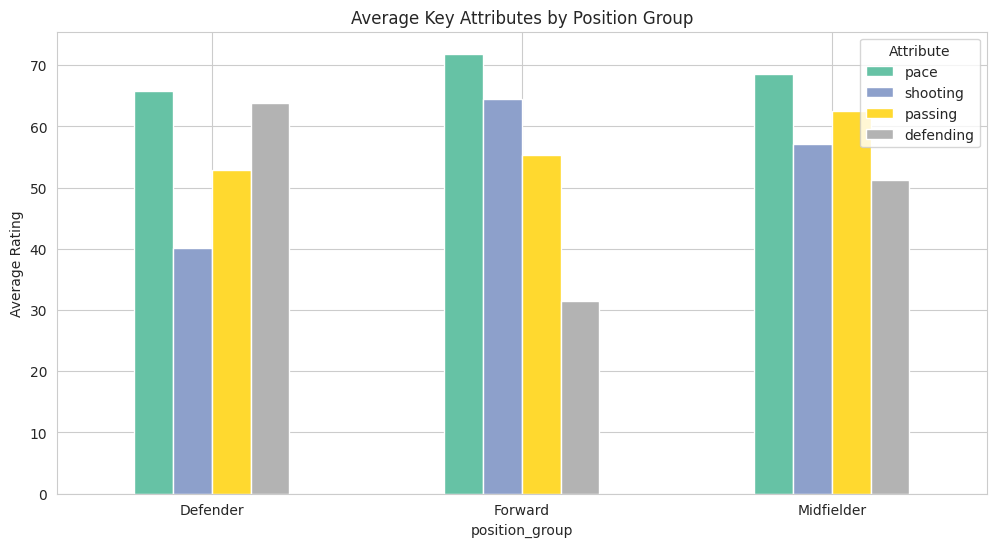

In [18]:
# Average pace, shooting, passing, defending by position group (excluding goalkeepers)
outfield = df[df['position_group'] != 'Goalkeeper']
attr_by_position = outfield.groupby('position_group')[['pace', 'shooting', 'passing', 'defending']].mean()

attr_by_position.plot(kind='bar', figsize=(12,6), colormap='Set2')
plt.title('Average Key Attributes by Position Group')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.legend(title='Attribute')
plt.show()

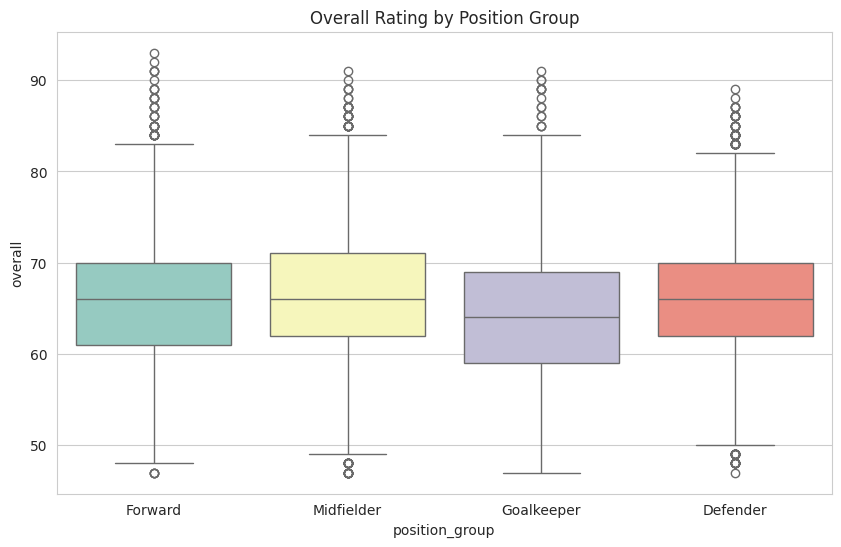

In [19]:
# Overall rating distribution by position group
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='position_group', y='overall', hue='position_group', palette='Set3', legend=False)
plt.title('Overall Rating by Position Group')
plt.show()

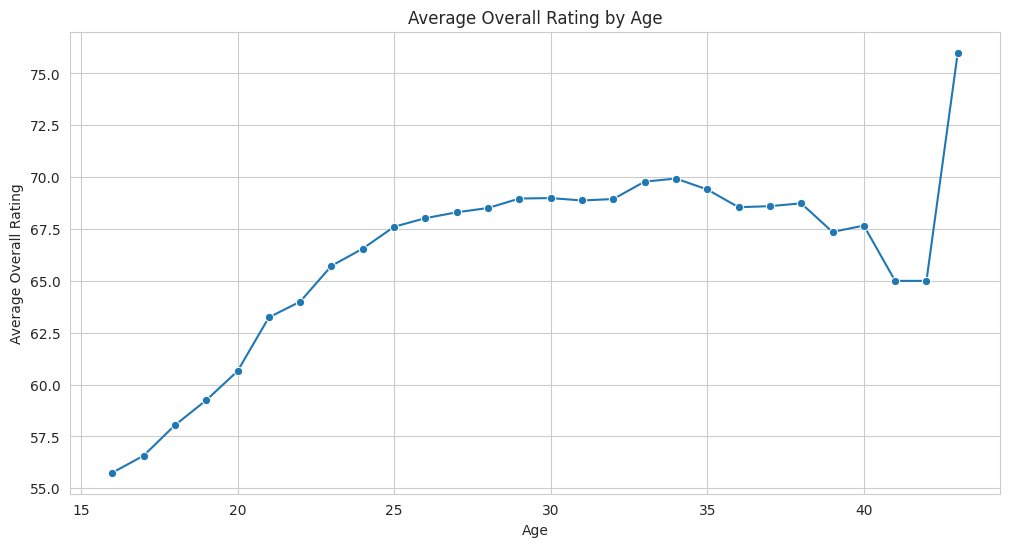

In [20]:
# Age vs overall - do players peak at a certain age?
age_overall = df.groupby('age')['overall'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=age_overall.index, y=age_overall.values, marker='o')
plt.title('Average Overall Rating by Age')
plt.xlabel('Age')
plt.ylabel('Average Overall Rating')
plt.show()

In [21]:
# Top 10 players by overall rating
top_players = df.sort_values('overall', ascending=False)[['short_name', 'club_name', 'position_group', 'overall', 'age']].head(10)
top_players

,short_name,club_name,position_group,overall,age
0,L. Messi,Paris Saint-Germain,Forward,93,34
1,R. Lewandowski,FC Bayern München,Forward,92,32
6,K. Mbappé,Paris Saint-Germain,Forward,91,22
2,Cristiano Ronaldo,Manchester United,Forward,91,36
4,K. De Bruyne,Manchester City,Midfielder,91,30
3,Neymar Jr,Paris Saint-Germain,Forward,91,29
5,J. Oblak,Atlético de Madrid,Goalkeeper,91,28
7,M. Neuer,FC Bayern München,Goalkeeper,90,35
10,N. Kanté,Chelsea,Midfielder,90,30
8,M. ter Stegen,FC Barcelona,Goalkeeper,90,29


**5. Multivariate / Value Analysis**

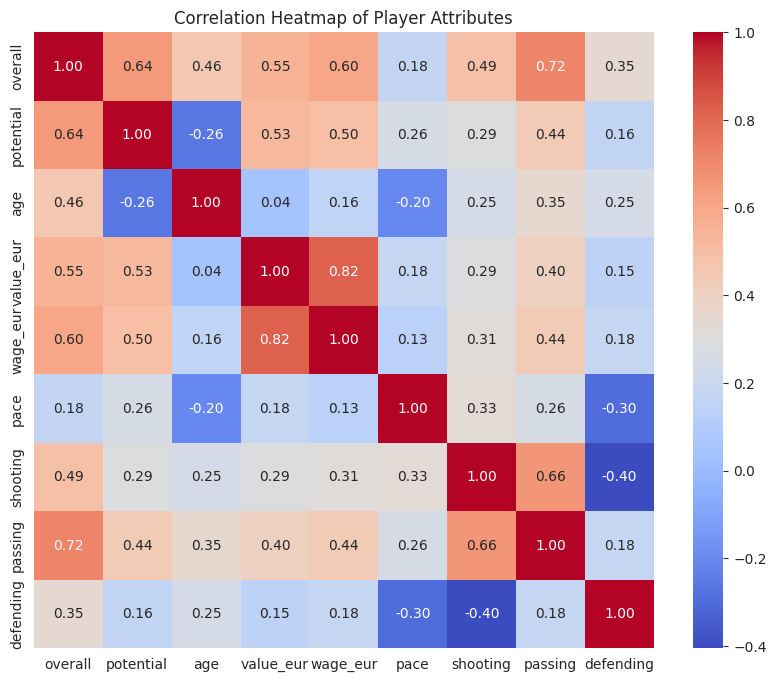

In [22]:
# Correlation heatmap
numeric_cols = ['overall', 'potential', 'age', 'value_eur', 'wage_eur', 'pace', 'shooting', 'passing', 'defending']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Player Attributes')
plt.show()

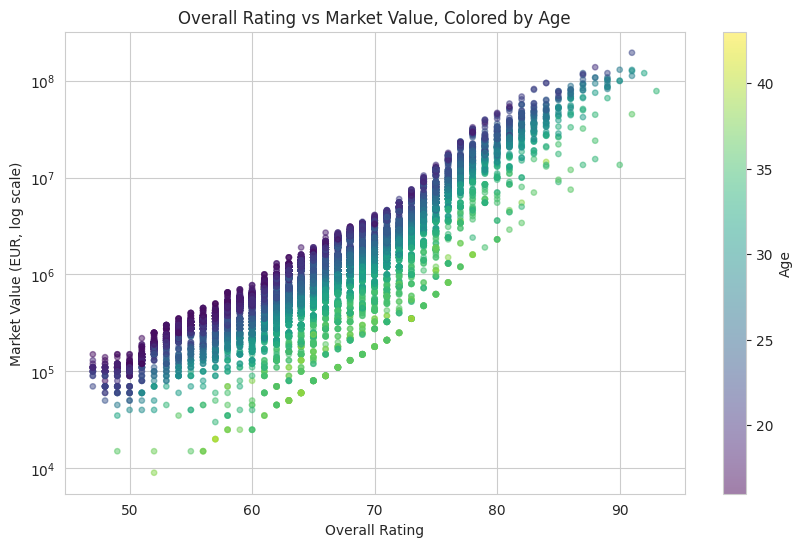

In [23]:
# Overall vs Value (log-scaled), colored by age
plt.figure(figsize=(10,6))
sc = plt.scatter(df['overall'], df['value_eur'], c=df['age'], cmap='viridis', alpha=0.5, s=15)
plt.yscale('log')
plt.colorbar(sc, label='Age')
plt.xlabel('Overall Rating')
plt.ylabel('Market Value (EUR, log scale)')
plt.title('Overall Rating vs Market Value, Colored by Age')
plt.show()

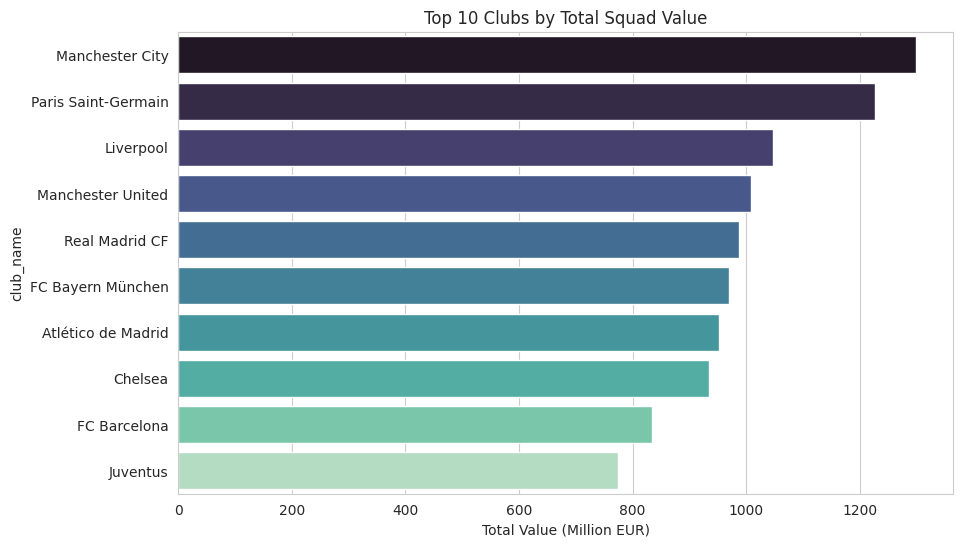

In [24]:
# Top 10 most valuable clubs
club_value = df.groupby('club_name')['value_eur'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=club_value.values / 1e6, y=club_value.index, hue=club_value.index, palette='mako', legend=False)
plt.title('Top 10 Clubs by Total Squad Value')
plt.xlabel('Total Value (Million EUR)')
plt.show()

In [25]:
# Best value players - high overall relative to wage (underrated players angle)
df['value_per_wage'] = df['overall'] / (df['wage_eur'] + 1)  # +1 to avoid divide by zero

best_value = df[df['wage_eur'] > 0].sort_values('value_per_wage', ascending=False)[
    ['short_name', 'club_name', 'position_group', 'overall', 'wage_eur']].head(10)
best_value

,short_name,club_name,position_group,overall,wage_eur
1450,A. Hložek,AC Sparta Praha,Forward,76,500.0
1467,A. Pyatov,Shakhtar Donetsk,Goalkeeper,75,500.0
2375,D. Akpeyi,Kaizer Chiefs,Goalkeeper,74,500.0
3654,C. Cáceda,FBC Melgar,Goalkeeper,72,500.0
3122,A. Gabbarini,LDU Quito,Goalkeeper,72,500.0
3819,I. Zabarnyi,Dynamo Kyiv,Defender,72,500.0
3825,M. Vušković,Hamburger SV,Defender,72,500.0
3779,A. Trubin,Shakhtar Donetsk,Goalkeeper,72,500.0
3883,A. Hruška,FC Viktoria Plzeň,Goalkeeper,71,500.0
3879,W. Sandilands,Orlando Pirates,Goalkeeper,71,500.0


**6. Insights Summary**

## Key Insights

- Forwards and midfielders show the widest attribute spread, while defenders cluster tightly around high defending/low shooting scores — attribute profiles clearly separate by position group.
- Player overall ratings peak around age [X] and decline afterward, consistent with typical athletic career curves.
- Market value is heavily right-skewed — a small number of elite players (mostly young, high-overall) account for disproportionate total value, confirmed by the log-transform comparison.
- [Club] has the highest total squad value among all clubs in the dataset.
- Overall rating and market value show a [strong/moderate] positive relationship, but age clearly modulates it — younger players with the same overall rating are valued much higher due to potential.
- The "best value" leaderboard surfaces several relatively low-wage, high-rated players — useful for spotting undervalued talent, similar to real-world scouting analysis.
- [Add 1-2 more insights specific to what you observed]